# Cohort Analysis and Retention Rate

en-US: **Task:**
We need to understand how long users stay active in our product. To do this, we will group users into cohorts based on their first event month. Then, we will calculate the percentage of users who return in the following months (Retention Rate).

ua: **Задача:**
Треба зрозуміти, як довго користувачі залишаються активними в продукті. Для цього ми розіб'ємо їх на групи (когорти) за місяцем найпершої дії і подивимось, який відсоток юзерів повертається у наступні місяці.

### Project Plan / План проєкту:
1. Data Generation / Підготовка та генерація тестових даних
2. Finding the Cohort / Визначення когорти (First Touch) для кожного користувача
3. Calculating Lifetime / Розрахунок "місяця життя" (Lifetime) для кожної події
4. Retention Matrix / Створення зведеної таблиці утримання (Pivot table)
5. Visualization / Побудова теплової карти (Heatmap) для пошуку інсайтів

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ГЕНЕРАЦИЯ ТЕСТОВЫХ ДАННЫХ

np.random.seed(42)
dates = pd.date_range('2023-01-01', periods=365, freq='D')
df = pd.DataFrame({
    'user_id': np.random.randint(1, 500, 3000),
    'event_date': np.random.choice(dates, 3000)
})

In [2]:
df.head()

,user_id,event_date
0,103,2023-09-20
1,436,2023-11-06
2,349,2023-06-21
3,271,2023-06-22
4,107,2023-12-28


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     3000 non-null   int32         
 1   event_date  3000 non-null   datetime64[us]
dtypes: datetime64[us](1), int32(1)
memory usage: 35.3 KB


## Step 1: Finding the Cohort / Шукаємо когорту

**en-US** To track retention, we must find the very first action of each user. The month of this first action becomes their "cohort".

**ua** Щоб рахувати утримання, нам треба знайти найпершу дію кожного користувача. Місяць цієї дії — це і є його "когорта".

In [4]:
first_order = df.groupby('user_id').agg({
    'event_date': 'min'
}).reset_index()

first_order['cohort_month'] = first_order['event_date'].dt.to_period('M')
first_order.head()

,user_id,event_date,cohort_month
0,1,2023-01-29,2023-01
1,2,2023-01-17,2023-01
2,3,2023-04-18,2023-04
3,4,2023-01-22,2023-01
4,5,2023-03-06,2023-03


## Step 2: Calculating Lifetime / Рахуємо Lifetime

**en-US** Now we join our cohort table with the main data. We need to calculate the "month of life" for each event (0 means the month of registration, 1 means the next month, etc.).

**ua** Тепер джоїнимо таблицю когорт з основними логами. Нам треба вирахувати, на який "місяць життя" юзера відбулася подія (0 місяць приходу, 1 наступний місяць і т.д.).

In [5]:
cohort_table = pd.merge(df, first_order, on = 'user_id', how='left')

In [6]:
cohort_table['month_number'] = (
        cohort_table['event_date_x'].dt.to_period('M') - cohort_table['cohort_month']
).apply(lambda x: x.n)

cohort_table.sort_values(by = ['user_id', 'month_number']).head()

,user_id,event_date_x,event_date_y,cohort_month,month_number
2745,1,2023-01-29,2023-01-29,2023-01,0
1164,1,2023-03-14,2023-01-29,2023-01,2
1037,1,2023-04-19,2023-01-29,2023-01,3
2711,1,2023-04-14,2023-01-29,2023-01,3
927,1,2023-05-30,2023-01-29,2023-01,4


## Step 3: Retention Matrix / Робимо матрицю Retention

**en-US** We group the data by cohort and month number to count unique active users. Then we create a pivot table and convert absolute numbers into percentages.

**ua** Групуємо дані за когортою та порядковим місяцем, рахуємо унікальних юзерів. Далі робимо зведену таблицю (pivot table) і переводимо абсолютні числа у відсотки.

In [7]:
retention_group = cohort_table.groupby(['cohort_month','month_number']).nunique().reset_index()
retention_group.sort_values(by = 'user_id')
retention_table = retention_group.pivot(index = 'cohort_month', columns = 'month_number', values = 'user_id')

rows = retention_table.iloc[:, 0]
final_tabel = retention_table.divide(rows, axis = 0).iloc[:, 1:] # starting from the first month after the event / починаючи з першого місяця після події
final_tabel

month_number,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,
2023-01,0.423077,0.346154,0.434066,0.434066,0.373626,0.434066,0.417582,0.351648,0.373626,0.428571,0.357143
2023-02,0.508621,0.439655,0.396552,0.370690,0.422414,0.387931,0.370690,0.387931,0.405172,0.387931,NaN
2023-03,0.333333,0.432099,0.370370,0.358025,0.407407,0.432099,0.333333,0.296296,0.444444,NaN,NaN
2023-04,0.387755,0.428571,0.448980,0.387755,0.448980,0.326531,0.367347,0.408163,NaN,NaN,NaN
2023-05,0.411765,0.470588,0.323529,0.382353,0.441176,0.323529,0.382353,NaN,NaN,NaN,NaN
2023-06,0.187500,0.250000,0.312500,NaN,0.562500,0.312500,NaN,NaN,NaN,NaN,NaN
2023-07,0.333333,0.500000,0.666667,0.166667,0.500000,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,0.333333,NaN,0.500000,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,0.166667,0.333333,0.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
retention_group.sort_values(by = 'user_id')

,cohort_month,month_number,user_id,event_date_x,event_date_y
71,2023-11,0,1,1,1
67,2023-09,1,1,2,1
70,2023-10,0,1,2,1
60,2023-07,4,1,1,1
69,2023-09,3,2,2,2
...,...,...,...,...,...
4,2023-01,4,79,28,27
3,2023-01,3,79,29,29
23,2023-03,0,81,29,27
12,2023-02,0,116,28,28


<Axes: xlabel='month_number', ylabel='cohort_month'>

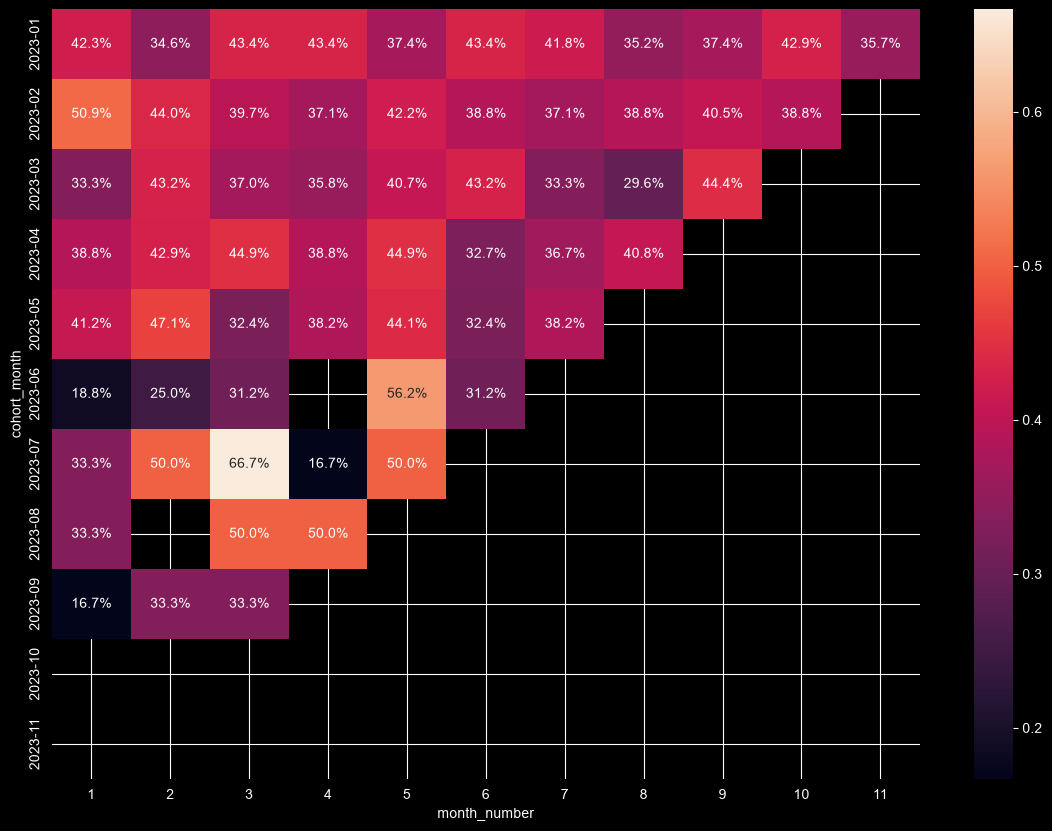

In [9]:
plt.figure(figsize=(14, 10))
sns.heatmap(
	final_tabel,
	annot=True,
	fmt='.1%',
)